In [1]:
# Ejecuta esta celda para instalar todo lo necesario en tu entorno de Jupyter
!pip install pandas pyreadstat jenkspy folium matplotlib

In [6]:
# Importamos las librerías necesarias para procesar los datos y calcular Jenks
import pandas as pd
import pyreadstat
import jenkspy
import sys

In [3]:
# Definimos la ruta exacta de tu archivo .sav en tu computadora
ruta_sav = r"C:\Users\gilme\OneDrive\Desktop\ENA_2014_2024\ENA_2014_2024.sav"

# Definimos la lista estricta de variables que necesitas (ignorando el resto de la base de datos)
variables_interes = [
    "ANIO", "NOMBREDD", "NOMBREPV", "NOMBREDI", "REGION", "DOMINIO", "FACTOR",
    "P204_NOM", "P204_TIPO", "P229D_EQUIV", "P206_INI_MES", "P206_INI_ANIO",
    "P209_MES", "P211_1", "P226", "P227",
    "LONGITUD", "LATITUD", "ALTITUD"
]

In [7]:
#Importamos los datos
try:
    df_ena, meta = pyreadstat.read_sav(ruta_sav, usecols=variables_interes, encoding="cp1252")
except Exception:
    try:
        df_ena, meta = pyreadstat.read_sav(ruta_sav, usecols=variables_interes, encoding="ISO-8859-1")
    except Exception:
        df_ena, meta = pyreadstat.read_sav(ruta_sav, usecols=variables_interes, encoding="latin1")
objeto_columnas_texto = df_ena.select_dtypes(include=['object']).columns
for col in objeto_columnas_texto:
    df_ena[col] = df_ena[col].astype(str).str.encode('utf-8', 'ignore').str.decode('utf-8', 'ignore')

C:\Users\gilme\AppData\Local\Temp\ipykernel_18096\3002775819.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  objeto_columnas_texto = df_ena.select_dtypes(include=['object']).columns


In [8]:
display(df_ena.head(5))
df_ena.info()

,ANIO,NOMBREDD,NOMBREPV,NOMBREDI,REGION,DOMINIO,FACTOR,P204_NOM,P204_TIPO,P206_INI_MES,P206_INI_ANIO,P209_MES,P211_1,P226,P227,LONGITUD,LATITUD,ALTITUD,P229D_EQUIV
0,2014.0,AMAZON,CHACHAPOYAS,CHACHAPOYAS,2.0,4.0,35.192727,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
1,2014.0,AMAZON,CHACHAPOYAS,CHACHAPOYAS,2.0,4.0,35.192727,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
2,2014.0,AMAZON,CHACHAPOYAS,CHACHAPOYAS,2.0,4.0,35.192727,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
3,2014.0,AMAZON,CHACHAPOYAS,CHACHAPOYAS,2.0,4.0,35.192727,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
4,2014.0,AMAZON,CHACHAPOYAS,CHACHAPOYAS,2.0,4.0,35.192727,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,


<class 'pandas.DataFrame'>
RangeIndex: 3843598 entries, 0 to 3843597
Data columns (total 19 columns):
 #   Column         Dtype  
---  ------         -----  
 0   ANIO           float64
 1   NOMBREDD       str    
 2   NOMBREPV       str    
 3   NOMBREDI       str    
 4   REGION         float64
 5   DOMINIO        float64
 6   FACTOR         float64
 7   P204_NOM       str    
 8   P204_TIPO      float64
 9   P206_INI_MES   float64
 10  P206_INI_ANIO  float64
 11  P209_MES       float64
 12  P211_1         float64
 13  P226           float64
 14  P227           float64
 15  LONGITUD       float64
 16  LATITUD        float64
 17  ALTITUD        float64
 18  P229D_EQUIV    str    
dtypes: float64(14), str(5)
memory usage: 659.8 MB


In [12]:
# Validamos que la columna sea numérica
df_ena['ALTITUD'] = pd.to_numeric(df_ena['ALTITUD'], errors='coerce')

# Revisamos cuántas filas tienen altitud real para el cálculo
total_datos = len(df_ena)
con_altitud = df_ena['ALTITUD'].notna().sum()

print(f"Total de filas en memoria: {total_datos}")
print(f"Filas con altitud válida para Jenks: {con_altitud}")
print(f"Filas sin altitud: {total_datos - con_altitud}")

print("\n--- RANGOS REALES DE ALTITUD ENCONTRADOS ---")
print(f"Altitud Mínima: {df_ena['ALTITUD'].min()} m s. n. m.")
print(f"Altitud Máxima: {df_ena['ALTITUD'].max()} m s. n. m.")

Total de filas en memoria: 3843598
Filas con altitud válida para Jenks: 12850
Filas sin altitud: 3830748

--- RANGOS REALES DE ALTITUD ENCONTRADOS ---
Altitud Mínima: 0.0 m s. n. m.
Altitud Máxima: 5163.0 m s. n. m.


In [14]:
print("--- BUSCANDO EL CULTIVO DE PAPA EN LA ENA ---")

# Filtramos las filas donde la variable del nombre del cultivo contenga "PAPA"
# Usamos .str.contains para capturar "PAPA BLANCA", "PAPA NATIVA", etc., ignorando mayúsculas/minúsculas
df_papa = df_ena[df_ena['P204_NOM'].str.contains('PAPA', na=False, case=False)]

total_papa = len(df_papa)

if total_papa == 0:
    print("⚠️ No se encontraron registros con la palabra 'PAPA' en 'P204_NOM'.")
    print("Vamos a mostrar los primeros cultivos disponibles para verificar cómo están escritos:")
    print(df_ena['P204_NOM'].dropna().unique()[:20])
else:
    # Contamos cuántos de estos registros de papa tienen altitud y coordenadas reales
    papa_con_coordenadas = df_papa['ALTITUD'].notna().sum()
    
    print(f"Total de registros de PAPA encontrados en la base de datos: {total_papa}")
    print(f"Registros de PAPA con ALTITUD/COORDENADAS reales (para el mapa): {papa_con_coordenadas}")
    print(f"Porcentaje de representatividad para el mapa: {(papa_con_coordenadas / total_papa)*100:.2f}%")
    
    print("\n--- TOP 10 LUGARES (DEPARTAMENTOS) CON MÁS DATOS DE PAPA ---")
    print(df_papa['NOMBREDD'].value_counts().head(50))

--- BUSCANDO EL CULTIVO DE PAPA EN LA ENA ---
Total de registros de PAPA encontrados en la base de datos: 128586
Registros de PAPA con ALTITUD/COORDENADAS reales (para el mapa): 605
Porcentaje de representatividad para el mapa: 0.47%

--- TOP 10 LUGARES (DEPARTAMENTOS) CON MÁS DATOS DE PAPA ---
NOMBREDD
PUNO             17600
                 12887
CUSCO            11353
HUANCAVELICA     10101
PASCO             7544
AYACUCHO          6856
HUANUCO           6571
ANCASH            6344
APURIMAC          5329
JUNIN             4967
LA LIBERTAD       4840
CAJAMARCA         4370
MOQUEGUA          3263
AREQUIPA          3008
JUNÃN            2315
AMAZONAS          2220
HUÃNUCO          1921
TACNA             1903
APURÃMAC         1651
LIMA              1636
HU?NUCO           1150
PIURA             1091
JUN?N              914
APUR?MAC           863
HUANCA             817
ICA                736
HUÃNU             724
APURÃ             689
AYACUC             666
LAMBAYEQUE         516
LORET

In [16]:
import pyreadstat
import pandas as pd
import numpy as np

print("--- IMPORTANDO Y REPARANDO CODIFICACIÓN DESDE EL ORIGEN ---")

# Intentamos primero con UTF-8, que es donde el INEI suele mantener las tildes nativas modernas
encodings_a_probar = ['utf-8', 'cp1252', 'ISO-8859-1', 'latin1']
df_ena = None
meta = None

for encoding_actual in encodings_a_probar:
    try:
        print(f"Probando lectura con codificación: {encoding_actual}...")
        df_ena, meta = pyreadstat.read_sav(ruta_sav, usecols=variables_interes, encoding=encoding_actual)
        print(f"¡Lectura exitosa con {encoding_actual}!")
        break
    except Exception as e:
        print(f"No se pudo leer con {encoding_actual}. Pasando al siguiente...")

# CORRECCIÓN DE SINTAXIS AQUÍ: Validación clásica
if df_ena is None:
    raise Exception("No se pudo leer el archivo con ninguna de las codificaciones estándar.")

# Reparación automática de strings corruptos a nivel de bytes
print("Reparando inconsistencias de texto remanentes...")
objeto_columnas_texto = df_ena.select_dtypes(include=['object']).columns

for col in objeto_columnas_texto:
    # Pasamos a texto string, limpiamos espacios en los extremos y convertimos a mayúsculas
    df_ena[col] = df_ena[col].astype(str).str.strip().str.upper()
    
    # Si la data venía con double encoding (ej: Ã en vez de Í), esto lo revierte de forma matemática:
    df_ena[col] = df_ena[col].apply(
        lambda x: x.encode('raw_unicode_escape').decode('utf-8', errors='ignore') 
        if any(c in x for c in ['Ã', 'Â', '?', '']) else x
    )
    
    # Convertimos los textos vacíos invisibles en valores nulos (NaN) reales
    df_ena[col] = df_ena[col].replace(r'^\s*$', np.nan, regex=True)
    df_ena[col] = df_ena[col].replace(['NAN', 'NONE', ''], np.nan)

print("¡Importación y limpieza de codificación terminada!")

--- IMPORTANDO Y REPARANDO CODIFICACIÓN DESDE EL ORIGEN ---
Probando lectura con codificación: utf-8...
No se pudo leer con utf-8. Pasando al siguiente...
Probando lectura con codificación: cp1252...
No se pudo leer con cp1252. Pasando al siguiente...
Probando lectura con codificación: ISO-8859-1...
¡Lectura exitosa con ISO-8859-1!
Reparando inconsistencias de texto remanentes...


C:\Users\gilme\AppData\Local\Temp\ipykernel_18096\4062369187.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  objeto_columnas_texto = df_ena.select_dtypes(include=['object']).columns


¡Importación y limpieza de codificación terminada!


In [20]:
print("--- COMPROBACIÓN DE DEPARTAMENTOS UNIFICADOS POR ENCODING ---")
df_papa_test = df_ena[df_ena['P204_NOM'].str.contains('PAPA', na=False, case=False)]
print(df_papa_test['NOMBREDD'].value_counts().head(200))
sum()

--- COMPROBACIÓN DE DEPARTAMENTOS UNIFICADOS POR ENCODING ---
NOMBREDD
PUNO             17600
CUSCO            11353
HUANCAVELICA     10101
PASCO             7544
AYACUCHO          6856
HUANUCO           6571
ANCASH            6344
APURIMAC          5329
JUNIN             4967
LA LIBERTAD       4840
CAJAMARCA         4370
MOQUEGUA          3263
AREQUIPA          3008
JUNÍN             2315
AMAZONAS          2220
HUÁNUCO           1921
TACNA             1903
APURÍMAC          1651
LIMA              1636
HU?NUCO           1150
PIURA             1091
JUN?N              914
APUR?MAC           863
HUANCA             817
ICA                736
HUÁNU              724
APURÍ              689
AYACUC             666
LAMBAYEQUE         516
LORETO             514
MADRE DE DIOS      489
CAJAMA             486
MOQUEG             445
LA LIB             413
UCAYALI            378
AMAZON             237
TUMBES             213
SAN MARTIN         201
AREQUI             173
MADRE               51
LAMBAY   

In [21]:
print("--- SUMA TOTAL DE REGISTROS DE PAPA ACTUAL ---")

# Tu misma línea pero guardada en una variable
conteos = df_ena[df_ena['P204_NOM'].str.contains('PAPA', na=False, case=False)]['NOMBREDD'].value_counts()

# Le aplicamos el sum() para contar absolutamente todo lo que listó
total_conteo = conteos.sum()

print(f"Total de registros contados en la lista de departamentos: {total_conteo}")

--- SUMA TOTAL DE REGISTROS DE PAPA ACTUAL ---
Total de registros contados en la lista de departamentos: 115699


In [22]:
import unicodedata
import re

print("--- UNIFICACIÓN GEOGRÁFICA DE DEPARTAMENTOS ---")

# Función para quitar tildes de forma automática
def eliminar_tildes(texto):
    if pd.isna(texto):
        return np.nan
    texto = str(texto).upper().strip()
    # Removemos acentos
    texto = ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')
    return texto

# 1. Aplicamos la remoción de tildes
df_ena['NOMBREDD_LIMPIO'] = df_ena['NOMBREDD'].apply(eliminar_tildes)

# 2. Reglas rápidas basadas en las primeras letras para capturar los nombres recortados o con '?'
def corregir_recortados(nombre):
    if pd.isna(nombre) or nombre in ['NAN', 'NONE', '']:
        return np.nan
    
    # Mapeo por aproximación de las primeras letras importantes
    if nombre.startswith('JUN') or 'JUN' in nombre: return 'JUNIN'
    if nombre.startswith('HUANU') or nombre.startswith('HUA') or 'HU' in nombre and 'NUC' in nombre: return 'HUANUCO'
    if nombre.startswith('APUR') or 'APU' in nombre: return 'APURIMAC'
    if nombre.startswith('SAN MAR') or 'SAN M' in nombre: return 'SAN MARTIN'
    if nombre.startswith('LA LIB'): return 'LA LIBERTAD'
    if nombre.startswith('CAJAM'): return 'CAJAMARCA'
    if nombre.startswith('MOQUE'): return 'MOQUEGUA'
    if nombre.startswith('AREQU'): return 'AREQUIPA'
    if nombre.startswith('AMAZO'): return 'AMAZONAS'
    if nombre.startswith('LAMBA'): return 'LAMBAYEQUE'
    if nombre.startswith('MADRE') or 'MAD' in nombre: return 'MADRE DE DIOS'
    if nombre.startswith('UCAYA'): return 'UCAYALI'
    if nombre.startswith('AYACU') or 'AYAC' in nombre: return 'AYACUCHO'
    if nombre.startswith('HUANCAV'): return 'HUANCAVELICA'
    if nombre.startswith('HUANCA'): return 'HUANCAVELICA' # Corrección para HUANCA
    
    return nombre

df_ena['NOMBREDD_LIMPIO'] = df_ena['NOMBREDD_LIMPIO'].apply(corregir_recortados)

print("\n--- CONTROL DE CALIDAD POST-REPARACIÓN AUTOMÁTICA ---")
df_papa_ok = df_ena[df_ena['P204_NOM'].str.contains('PAPA', na=False, case=False)]
print(df_papa_ok['NOMBREDD_LIMPIO'].value_counts().head(15))

--- UNIFICACIÓN GEOGRÁFICA DE DEPARTAMENTOS ---

--- CONTROL DE CALIDAD POST-REPARACIÓN AUTOMÁTICA ---
NOMBREDD_LIMPIO
HUANUCO        21284
PUNO           17600
CUSCO          11353
APURIMAC        8532
JUNIN           8196
PASCO           7544
AYACUCHO        7522
ANCASH          6344
LA LIBERTAD     5253
CAJAMARCA       4856
MOQUEGUA        3708
AREQUIPA        3181
AMAZONAS        2457
TACNA           1903
LIMA            1636
Name: count, dtype: int64


In [23]:
print("--- SUMATORIA TOTAL DE DEPARTAMENTOS UNIFICADOS (PAPA) ---")

# Filtramos papa con tu variable limpia
df_papa_ok = df_ena[df_ena['P204_NOM'].str.contains('PAPA', na=False, case=False)]

# Obtenemos los conteos de la columna limpia
conteos_limpios = df_papa_ok['NOMBREDD_LIMPIO'].value_counts()

# Mostramos el desglose completo para que verifiques que ya no hay repetidos
print(conteos_limpios)

print("\n--------------------------------------------------")
# Contamos el total sumando los valores del value_counts()
print(f"SUMA TOTAL DE REGISTROS EN LA LISTA LIMPIA: {conteos_limpios.sum()}")
print("--------------------------------------------------")

# Verificamos si quedaron celdas vacías que el script transformó a NaN
vacios_restantes = df_papa_ok['NOMBREDD_LIMPIO'].isna().sum()
print(f"Registros que eran espacios en blanco (ahora NaN reales): {vacios_restantes}")
print(f"Suma total absoluta (Limpia + Vacíos): {conteos_limpios.sum() + vacios_restantes}")

--- SUMATORIA TOTAL DE DEPARTAMENTOS UNIFICADOS (PAPA) ---
NOMBREDD_LIMPIO
HUANUCO          21284
PUNO             17600
CUSCO            11353
APURIMAC          8532
JUNIN             8196
PASCO             7544
AYACUCHO          7522
ANCASH            6344
LA LIBERTAD       5253
CAJAMARCA         4856
MOQUEGUA          3708
AREQUIPA          3181
AMAZONAS          2457
TACNA             1903
LIMA              1636
PIURA             1091
ICA                736
LAMBAYEQUE         565
MADRE DE DIOS      540
LORETO             514
UCAYALI            390
SAN MARTIN         281
TUMBES             213
Name: count, dtype: int64

--------------------------------------------------
SUMA TOTAL DE REGISTROS EN LA LISTA LIMPIA: 115699
--------------------------------------------------
Registros que eran espacios en blanco (ahora NaN reales): 12887
Suma total absoluta (Limpia + Vacíos): 128586


In [24]:
print("--- VARIETALES DE PAPA ENCONTRADOS EN LA ENA ---")
# Buscamos todas las filas que contengan la palabra PAPA y vemos sus nombres exactos
variedades_papa = df_ena[df_ena['P204_NOM'].str.contains('PAPA', na=False, case=False)]['P204_NOM'].value_counts()
print(variedades_papa)

--- VARIETALES DE PAPA ENCONTRADOS EN LA ENA ---
P204_NOM
PAPA BLANCA      64094
PAPA NATIVA      33105
PAPA COLOR        8977
PAPA AMARILLA     7984
PAPA HUAYRO       5584
PAPAYA            5418
PAPA AMARGA       2650
SACHAPAPA          471
PAPAYUELA          299
PAPA JAPONESA        3
PAPA ALIANZA         1
Name: count, dtype: int64


In [27]:
import pandas as pd
import numpy as np

# Aseguramos la instalación de la librería experta en Jenks
import jenkspy

print("--- 1. FILTRADO Y CLASIFICACIÓN DE VERDADERAS VARIETALES DE PAPA ---")

# Lista de cultivos que SÍ son papas (excluyendo papaya, sachapapa, papayuela)
papas_verdaderas = [
    'PAPA BLANCA', 'PAPA NATIVA', 'PAPA COLOR', 'PAPA AMARILLA', 
    'PAPA HUAYRO', 'PAPA AMARGA', 'PAPA JAPONESA', 'PAPA ALIANZA'
]

# Filtramos la base de datos original usando la lista estricta
df_papa = df_ena[df_ena['P204_NOM'].isin(papas_verdaderas)].copy()

# Agrupamos en Macro-Variedades para un análisis agronómico más rico
def clasificar_grupo_papa(nombre):
    if nombre in ['PAPA NATIVA', 'PAPA AMARGA']:
        return 'NATIVA/AMARGA (Resistente/Altura)'
    else:
        return 'COMERCIAL/MODERNA (Valle/Mercado)'

df_papa['GRUPO_PAPA'] = df_papa['P204_NOM'].apply(clasificar_grupo_papa)


print("\n--- 2. IMPUTACIÓN JERÁRQUICA DE ALTITUD POR UBIGEO (RESCATE DE FILAS) ---")

# Calculamos promedios basados en nuestra columna regional limpia, provincias y distritos
alt_distrito = df_papa.groupby(['NOMBREDD_LIMPIO', 'NOMBREPV', 'NOMBREDI'])['ALTITUD'].transform('mean')
alt_provincia = df_papa.groupby(['NOMBREDD_LIMPIO', 'NOMBREPV'])['ALTITUD'].transform('mean')
alt_depto = df_papa.groupby(['NOMBREDD_LIMPIO'])['ALTITUD'].transform('mean')
alt_global = df_papa['ALTITUD'].mean()

# Rellenamos los vacíos de altitud en cascada georreferenciada
df_papa['ALTITUD_FINAL'] = df_papa['ALTITUD'].fillna(alt_distrito).fillna(alt_provincia).fillna(alt_depto).fillna(alt_global)


print("\n--- 3. ALGORITMO DE BRECHAS NATURALES DE JENKS (DATA PURA) ---")

# Extraemos las altitudes numéricas reales y únicas medidas en campo con GPS para entrenar a Jenks
altitudes_entrenamiento = df_papa['ALTITUD'].dropna().unique().tolist()

# CORRECCIÓN AQUÍ: Cambiamos nb_class por n_classes
cortes_jenks = jenkspy.jenks_breaks(altitudes_entrenamiento, n_classes=8)

print("\n¡Límites calculados con éxito por Jenks para el cultivo de Papa!")
for i in range(len(cortes_jenks)-1):
    print(f" -> Piso {i+1}: Desde {cortes_jenks[i]:.1f} hasta {cortes_jenks[i+1]:.1f} m s. n. m.")


print("\n--- 4. ASIGNACIÓN DE PISOS ECOLÓGICOS A TODA LA DATA ---")

def etiquetar_piso(altitud):
    if pd.isna(altitud):
        return "Sin Piso"
    # Etiquetas profesionales de pisos altitudinales peruanos
    nombres_pisos = ["Piso 1", "Piso 2", "Piso 3", "Piso 4", "Piso 5", "Piso 6", "Piso 7", "Piso 8"]
    for i in range(len(cortes_jenks)-1):
        if cortes_jenks[i] <= altitud <= cortes_jenks[i+1]:
            return nombres_pisos[i]
    return "Sin Piso"

df_papa['PISO_JENKS'] = df_papa['ALTITUD_FINAL'].apply(etiquetar_piso)


print("\n------------------------------------------------------------")
print("--- MATRIZ DE DISTRIBUCIÓN: GRUPO DE PAPA vs PISO ECOLÓGICO ---")
print("------------------------------------------------------------")
# Cruzamos los grupos de papa con los pisos calculados por Jenks
matriz_cruce = pd.crosstab(df_papa['PISO_JENKS'], df_papa['GRUPO_PAPA'], margins=True, margins_name="Total General")
print(matriz_cruce)

--- 1. FILTRADO Y CLASIFICACIÓN DE VERDADERAS VARIETALES DE PAPA ---

--- 2. IMPUTACIÓN JERÁRQUICA DE ALTITUD POR UBIGEO (RESCATE DE FILAS) ---

--- 3. ALGORITMO DE BRECHAS NATURALES DE JENKS (DATA PURA) ---

¡Límites calculados con éxito por Jenks para el cultivo de Papa!
 -> Piso 1: Desde 6.0 hasta 1038.0 m s. n. m.
 -> Piso 2: Desde 1038.0 hasta 2394.0 m s. n. m.
 -> Piso 3: Desde 2394.0 hasta 2977.0 m s. n. m.
 -> Piso 4: Desde 2977.0 hasta 3357.0 m s. n. m.
 -> Piso 5: Desde 3357.0 hasta 3677.0 m s. n. m.
 -> Piso 6: Desde 3677.0 hasta 3989.0 m s. n. m.
 -> Piso 7: Desde 3989.0 hasta 4325.0 m s. n. m.
 -> Piso 8: Desde 4325.0 hasta 5163.0 m s. n. m.

--- 4. ASIGNACIÓN DE PISOS ECOLÓGICOS A TODA LA DATA ---

------------------------------------------------------------
--- MATRIZ DE DISTRIBUCIÓN: GRUPO DE PAPA vs PISO ECOLÓGICO ---
------------------------------------------------------------
GRUPO_PAPA     COMERCIAL/MODERNA (Valle/Mercado)  \
PISO_JENKS                              

In [28]:
print("--- INSPECCIÓN DE VARIABLES GEOGRÁFICAS DISPONIBLES EN LA DATA ---")

# Columnas candidatas a contener geolocalización o ubigeo
columnas_geo = [col for col in df_papa.columns if any(x in col.upper() for x in ['LAT', 'LON', 'ALT', 'UBI', 'DEPT', 'PROV', 'DIST', 'CONGLOMERADO'])]

print("Variables encontradas relacionadas a geografía:")
print(columnas_geo)
print("\n--- MUESTRA DE LAS PRIMERAS 5 FILAS (ENFOQUE GEOGRÁFICO) ---")
# Mostramos las columnas clave para auditar su contenido real
columnas_clave = ['NOMBREDD_LIMPIO', 'NOMBREPV', 'NOMBREDI', 'ALTITUD', 'ALTITUD_FINAL', 'PISO_JENKS']
# Si existen variables de latitud o longitud en tu base de datos, las agregamos dinámicamente para verlas
for coord in ['LATITUD', 'LONGITUD', 'GPS_LAT', 'GPS_LON']:
    if coord in df_papa.columns:
        columnas_clave.append(coord)

print(df_papa[columnas_clave].head())

print("\n--- AUDITORÍA DE PUNTOS GPS REALES ---")
if 'LATITUD' in df_papa.columns or 'GPS_LAT' in df_papa.columns:
    col_lat = 'LATITUD' if 'LATITUD' in df_papa.columns else 'GPS_LAT'
    con_coordenadas = df_papa[col_lat].notna().sum()
    print(f"Registros de papa con coordenadas GPS directas (puntos): {con_coordenadas} de {len(df_papa)}")
else:
    print("No se encontraron columnas nativas de Latitud/Longitud con esos nombres exactos en el archivo.")

--- INSPECCIÓN DE VARIABLES GEOGRÁFICAS DISPONIBLES EN LA DATA ---
Variables encontradas relacionadas a geografía:
['LONGITUD', 'LATITUD', 'ALTITUD', 'ALTITUD_FINAL']

--- MUESTRA DE LAS PRIMERAS 5 FILAS (ENFOQUE GEOGRÁFICO) ---
    NOMBREDD_LIMPIO     NOMBREPV     NOMBREDI  ALTITUD  ALTITUD_FINAL  \
48         AMAZONAS  CHACHAPOYAS  CHACHAPOYAS      NaN         2916.5   
125        AMAZONAS  CHACHAPOYAS       BALSAS      NaN         2916.5   
177        AMAZONAS  CHACHAPOYAS       BALSAS      NaN         2916.5   
178        AMAZONAS  CHACHAPOYAS       BALSAS      NaN         2916.5   
254        AMAZONAS  CHACHAPOYAS  CHUQUIBAMBA      NaN         2916.5   

    PISO_JENKS  LATITUD  LONGITUD  
48      Piso 3      NaN       NaN  
125     Piso 3      NaN       NaN  
177     Piso 3      NaN       NaN  
178     Piso 3      NaN       NaN  
254     Piso 3      NaN       NaN  

--- AUDITORÍA DE PUNTOS GPS REALES ---
Registros de papa con coordenadas GPS directas (puntos): 568 de 122398


In [29]:
print("--- PREPARANDO TABLA DE ATRIBUTOS PARA EL MAPA DE PUNO ---")

# 1. Filtramos la data final de papas solo para la región Puno
df_papa_puno = df_papa[df_papa['NOMBREDD_LIMPIO'] == 'PUNO'].copy()

# 2. Agrupamos por Provincia para calcular estadísticas clave
mapa_data = df_papa_puno.groupby('NOMBREPV').agg(
    Total_Productores=('PISO_JENKS', 'count'),
    Altitud_Media=('ALTITUD_FINAL', 'mean'),
    # Calculamos el % de papa nativa/amarga en la provincia
    Productores_Nativa=('GRUPO_PAPA', lambda x: (x == 'NATIVA/AMARGA (Resistente/Altura)').sum())
).reset_index()

# Calculamos el porcentaje real de representatividad de papa nativa
mapa_data['Porcentaje_Nativa'] = (mapa_data['Productores_Nativa'] / mapa_data['Total_Productores']) * 100

# 3. Determinamos matemáticamente cuál es el Piso de Jenks que domina en cada provincia
piso_dominante = df_papa_puno.groupby('NOMBREPV')['PISO_JENKS'].agg(lambda x: x.value_counts().index[0]).reset_index()
piso_dominante.columns = ['NOMBREPV', 'PISO_PREDOMINANTE']

# Unimos todo en un solo DataFrame estructural
tabla_mapa_puno = pd.merge(mapa_data, piso_dominante, on='NOMBREPV')

print("\n--- DATA LISTA PARA ACOPLAR AL SHAPEFILE (.SHP) ---")
print(tabla_mapa_puno.sort_values(by='Altitud_Media', ascending=False))

# Guardamos esta tabla para tener el respaldo numérico exacto del mapa
tabla_mapa_puno.to_csv("datos_mapa_provincias_puno.csv", index=False)
print("\n Archivo 'datos_mapa_provincias_puno.csv' exportado con éxito.")

--- PREPARANDO TABLA DE ATRIBUTOS PARA EL MAPA DE PUNO ---

--- DATA LISTA PARA ACOPLAR AL SHAPEFILE (.SHP) ---
                 NOMBREPV  Total_Productores  Altitud_Media  \
1                CARABAYA                834    4318.778477   
9   SAN ANTONIO DE PUTINA                266    4088.000000   
11                 SANDIA                505    4057.094257   
0                AZANGARO               2385    4024.429674   
10              SAN ROMAN                512    4018.000000   
6                  MELGAR                661    3992.675000   
5                   LAMPA                409    3992.675000   
4                HUANCANE               2271    3992.434720   
8                    PUNO               2804    3924.011421   
2                CHUCUITO               2209    3921.453724   
12                YUNGUYO               1251    3885.996243   
7                    MOHO                885    3885.439548   
3               EL COLLAO               2420    3868.472624   

    P

In [35]:
df_papa_puno.head()

,ANIO,NOMBREDD,NOMBREPV,NOMBREDI,REGION,DOMINIO,FACTOR,P204_NOM,P204_TIPO,P206_INI_MES,...,P226,P227,LONGITUD,LATITUD,ALTITUD,P229D_EQUIV,NOMBREDD_LIMPIO,GRUPO_PAPA,ALTITUD_FINAL,PISO_JENKS
159208,2014.0,PUNO,PUNO,PUNO,2.0,6.0,162.719048,PAPA NATIVA,1.0,3.0,...,1.0,5.0,NaN,NaN,NaN,NaN,PUNO,NATIVA/AMARGA (Resistente/Altura),4158.0,Piso 7
159209,2014.0,PUNO,PUNO,PUNO,2.0,6.0,162.719048,PAPA COLOR,1.0,5.0,...,1.0,1.0,NaN,NaN,NaN,NaN,PUNO,COMERCIAL/MODERNA (Valle/Mercado),4158.0,Piso 7
159211,2014.0,PUNO,PUNO,PUNO,2.0,6.0,162.719048,PAPA NATIVA,1.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,PUNO,NATIVA/AMARGA (Resistente/Altura),4158.0,Piso 7
159212,2014.0,PUNO,PUNO,PUNO,2.0,6.0,162.719048,PAPA NATIVA,1.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,PUNO,NATIVA/AMARGA (Resistente/Altura),4158.0,Piso 7
159220,2014.0,PUNO,PUNO,PUNO,2.0,6.0,162.719048,PAPA NATIVA,1.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,PUNO,NATIVA/AMARGA (Resistente/Altura),4158.0,Piso 7


In [43]:
# 1. Lista estricta de variedades de papa
papas_verdaderas = ['PAPA BLANCA', 'PAPA NATIVA', 'PAPA COLOR', 'PAPA AMARILLA', 'PAPA HUAYRO', 'PAPA AMARGA', 'PAPA JAPONESA', 'PAPA ALIANZA']

# 2. El "Filtro Absoluto" para el distrito de Puno con datos GPS reales
df_puno_distrito_puro = df_ena[
    (df_ena['NOMBREDD_LIMPIO'] == 'PUNO') &          # 1. Departamento: Puno
    (df_ena['NOMBREPV'] == 'PUNO') &                 # 2. Provincia: Puno
    (df_ena['NOMBREDI'] == 'PUNO') &                 # 3. Distrito: Puno
    (df_ena['ALTITUD'].notna()) &                    # 4. Que SÍ tenga altitud medida
    (df_ena['P204_NOM'].isin(papas_verdaderas))      # 5. Que SÍ sea cultivo de papa
]

# 3. Columnas clave para ver en pantalla
columnas_clave = ['NOMBREPV', 'NOMBREDI', 'P204_NOM', 'ALTITUD', 'LONGITUD', 'LATITUD']

# Mostramos las filas que cumplan con esta condición estricta
print(f"Cantidad de parcelas encontradas con GPS real en el distrito de Puno: {len(df_puno_distrito_puro)}")
df_puno_distrito_puro[columnas_clave].head(100)

Cantidad de parcelas encontradas con GPS real en el distrito de Puno: 1


,NOMBREPV,NOMBREDI,P204_NOM,ALTITUD,LONGITUD,LATITUD
159293,PUNO,PUNO,PAPA NATIVA,4158.0,-70.101265,-15.882042


In [50]:
print("--- CONTEO DE REGISTROS TOTALES vs REGISTROS CON DATOS FÍSICOS COMPLETOS ---")

# 1. Identificamos las filas que tienen Longitud, Latitud Y Altitud llenas al mismo tiempo
tiene_datos_fisicos = df_ena['LONGITUD'].notna() & df_ena['LATITUD'].notna() & df_ena['ALTITUD'].notna()

# 2. Creamos la tabla cruzada por Departamento
conteo_total = df_ena['NOMBREDD_LIMPIO'].value_counts().rename('Total_Registros_ENA')
conteo_con_datos = df_ena[tiene_datos_fisicos]['NOMBREDD_LIMPIO'].value_counts().rename('Con_Datos_Fisicos_Completos')

# 3. Juntamos ambos conteos en una sola tabla
tabla_comparativa = pd.concat([conteo_total, conteo_con_datos], axis=1).fillna(0).astype(int)

# 4. Agregamos el porcentaje para ver el peso real de los datos completos
tabla_comparativa['%_Datos_Completos'] = (tabla_comparativa['Con_Datos_Fisicos_Completos'] / tabla_comparativa['Total_Registros_ENA']) * 100

print(tabla_comparativa.sort_values(by='Total_Registros_ENA', ascending=False))

--- CONTEO DE REGISTROS TOTALES vs REGISTROS CON DATOS FÍSICOS COMPLETOS ---
                 Total_Registros_ENA  Con_Datos_Fisicos_Completos  \
NOMBREDD_LIMPIO                                                     
HUANUCO                       356484                          867   
PUNO                          256621                          522   
CAJAMARCA                     239276                          518   
CUSCO                         225582                          496   
ANCASH                        219098                          567   
AYACUCHO                      216579                          400   
APURIMAC                      180268                          423   
AMAZONAS                      157714                          442   
LA LIBERTAD                   154189                          562   
MOQUEGUA                      141219                          349   
AREQUIPA                      140829                          453   
JUNIN                     

--- 1. FILTRANDO DATA CRUDA NACIONAL (SOLO PUNTOS COMPLETOS DE PAPA) ---
-> Total de parcelas con GPS real completo en el país: 568

--- 2. ENTRENANDO JENKS CON DATA PURA NACIONAL ---
¡Límites calculados con éxito por Jenks!
 -> Piso 1: Desde 6.0 hasta 1038.0 m s. n. m.
 -> Piso 2: Desde 1038.0 hasta 2394.0 m s. n. m.
 -> Piso 3: Desde 2394.0 hasta 2977.0 m s. n. m.
 -> Piso 4: Desde 2977.0 hasta 3357.0 m s. n. m.
 -> Piso 5: Desde 3357.0 hasta 3677.0 m s. n. m.
 -> Piso 6: Desde 3677.0 hasta 3989.0 m s. n. m.
 -> Piso 7: Desde 3989.0 hasta 4325.0 m s. n. m.
 -> Piso 8: Desde 4325.0 hasta 5163.0 m s. n. m.

--- 3. ASIGNACIÓN DE PISOS ECOLÓGICOS REALES ---

--- 4. PINTANDO EL MAPA REAL DIRECTO EN EL NOTEBOOK ---


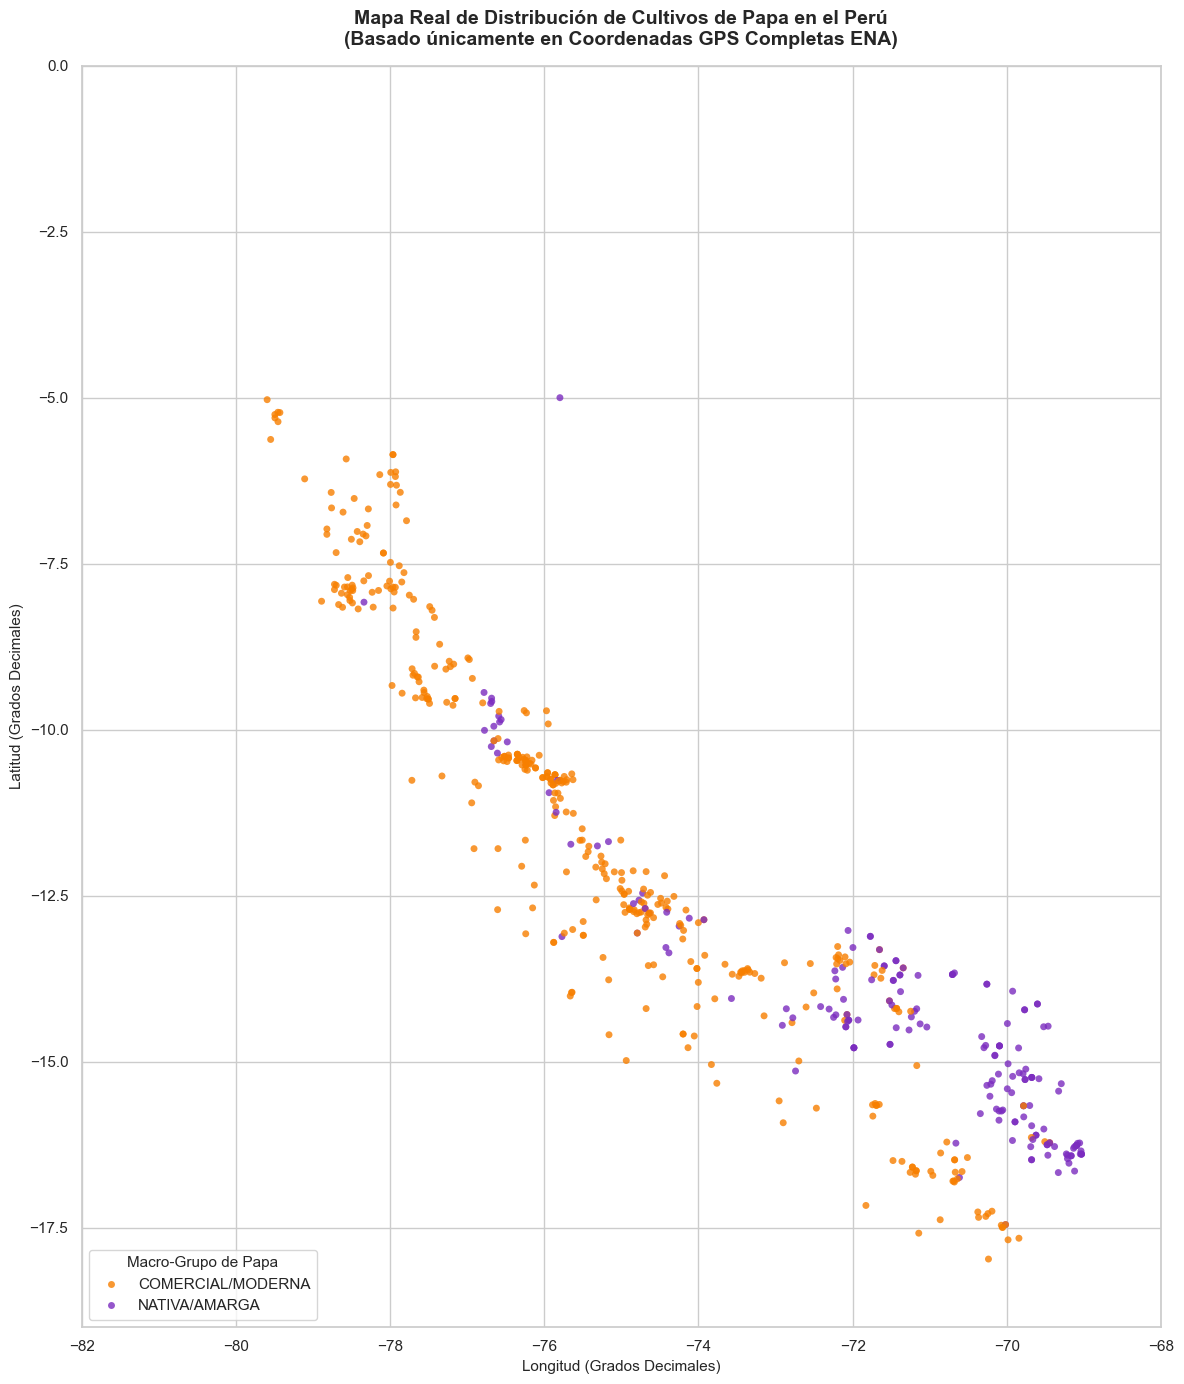


--- 5. MATRIZ DE CONTROL DE DATOS PURAS EN EL PAÍS ---
GRUPO_PAPA     COMERCIAL/MODERNA  NATIVA/AMARGA  Total General
PISO_JENKS                                                    
Piso 1                        13              1             14
Piso 2                        21              0             21
Piso 3                        47              2             49
Piso 4                        72              4             76
Piso 5                        67             12             79
Piso 6                        75             82            157
Piso 7                        73             56            129
Piso 8                        21             22             43
Total General                389            179            568


In [47]:
import pandas as pd
import numpy as np
import jenkspy
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 1. FILTRANDO DATA CRUDA NACIONAL (SOLO PUNTOS COMPLETOS DE PAPA) ---")

# Lista estricta de papas verdaderas
papas_verdaderas = [
    'PAPA BLANCA', 'PAPA NATIVA', 'PAPA COLOR', 'PAPA AMARILLA', 
    'PAPA HUAYRO', 'PAPA AMARGA', 'PAPA JAPONESA', 'PAPA ALIANZA'
]

# Filtro Absoluto: Es Papa + Datos Físicos Completos (Sin NaN en Lat, Lon ni Altitud) en TODO EL PERÚ
df_papa_real = df_ena[
    (df_ena['P204_NOM'].isin(papas_verdaderas)) &
    (df_ena['LONGITUD'].notna()) &
    (df_ena['LATITUD'].notna()) &
    (df_ena['ALTITUD'].notna())
].copy()

# Clasificación rápida de Macro-Variedades
df_papa_real['GRUPO_PAPA'] = df_papa_real['P204_NOM'].apply(
    lambda x: 'NATIVA/AMARGA' if x in ['PAPA NATIVA', 'PAPA AMARGA'] else 'COMERCIAL/MODERNA'
)

print(f"-> Total de parcelas con GPS real completo en el país: {len(df_papa_real)}")


print("\n--- 2. ENTRENANDO JENKS CON DATA PURA NACIONAL ---")

# Extraemos altitudes reales únicas para calibrar los pisos ecológicos reales
altitudes_puras = df_papa_real['ALTITUD'].unique().tolist()
cortes_jenks = jenkspy.jenks_breaks(altitudes_puras, n_classes=8)

print("¡Límites calculados con éxito por Jenks!")
for i in range(len(cortes_jenks)-1):
    print(f" -> Piso {i+1}: Desde {cortes_jenks[i]:.1f} hasta {cortes_jenks[i+1]:.1f} m s. n. m.")


print("\n--- 3. ASIGNACIÓN DE PISOS ECOLÓGICOS REALES ---")

def etiquetar_piso_real(altitud):
    nombres_pisos = ["Piso 1", "Piso 2", "Piso 3", "Piso 4", "Piso 5", "Piso 6", "Piso 7", "Piso 8"]
    for i in range(len(cortes_jenks)-1):
        if cortes_jenks[i] <= altitud <= cortes_jenks[i+1]:
            return nombres_pisos[i]
    return "Sin Piso"

df_papa_real['PISO_JENKS'] = df_papa_real['ALTITUD'].apply(etiquetar_piso_real)


print("\n--- 4. PINTANDO EL MAPA REAL DIRECTO EN EL NOTEBOOK ---")

# Configuramos el lienzo del gráfico estático
plt.figure(figsize=(12, 14))
sns.set_theme(style="whitegrid")

# Paleta de colores profesional para contrastar las variedades
paleta_colores = {'NATIVA/AMARGA': '#7B2CBF', 'COMERCIAL/MODERNA': '#F77F00'} # Morado y Naranja

# Dibujamos la dispersión de coordenadas geográficas reales (Longitud = X, Latitud = Y)
sns.scatterplot(
    data=df_papa_real,
    x='LONGITUD',
    y='LATITUD',
    hue='GRUPO_PAPA',
    palette=paleta_colores,
    alpha=0.8,
    s=25,
    edgecolor='none'
)

# Estética y rotulación formal del mapa
plt.title("Mapa Real de Distribución de Cultivos de Papa en el Perú\n(Basado únicamente en Coordenadas GPS Completas ENA)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Longitud (Grados Decimales)", fontsize=11)
plt.ylabel("Latitud (Grados Decimales)", fontsize=11)
plt.legend(title="Macro-Grupo de Papa", title_fontsize='11', loc='lower left', frameon=True)

# Ajustamos ejes para encuadrar la silueta geográfica del Perú
plt.xlim(-82, -68)
plt.ylim(-19, 0)

# Renderizamos el mapa directamente en la celda del Jupyter
plt.tight_layout()
plt.show()

print("\n--- 5. MATRIZ DE CONTROL DE DATOS PURAS EN EL PAÍS ---")
matriz_cruce_real = pd.crosstab(df_papa_real['PISO_JENKS'], df_papa_real['GRUPO_PAPA'], margins=True, margins_name="Total General")
print(matriz_cruce_real)

In [51]:
import folium
from folium.plugins import MarkerCluster
import pandas as pd
import jenkspy

print("--- INICIANDO MAPEO INTERACTIVO DE PAPA CON COORDENADAS COMPLETAS ---")

# 1. LISTA ESTRICTA DE VARIETALES VERDADERAS DE PAPA
papas_verdaderas = [
    'PAPA BLANCA', 'PAPA NATIVA', 'PAPA COLOR', 'PAPA AMARILLA', 
    'PAPA HUAYRO', 'PAPA AMARGA', 'PAPA JAPONESA', 'PAPA ALIANZA'
]

# 2. FILTRO COMPLETO: Solo papa + coordenadas físicas 100% reales en todo el Perú
df_papa_mapeable = df_ena[
    (df_ena['P204_NOM'].isin(papas_verdaderas)) &
    (df_ena['LONGITUD'].notna()) &
    (df_ena['LATITUD'].notna()) &
    (df_ena['ALTITUD'].notna())
].copy()

# Clasificación macro-agronómica rápida para los colores
df_papa_mapeable['GRUPO_PAPA'] = df_papa_mapeable['P204_NOM'].apply(
    lambda x: 'NATIVA/AMARGA' if x in ['PAPA NATIVA', 'PAPA AMARGA'] else 'COMERCIAL/MODERNA'
)

print(f"-> Cantidad total de puntos de papa que se van a dibujar: {len(df_papa_mapeable)}")


# 3. ENTRENAMIENTO DE JENKS CON LAS ALTITUDES REALES DE PAPA
altitudes_reales = df_papa_mapeable['ALTITUD'].unique().tolist()
cortes_jenks = jenkspy.jenks_breaks(altitudes_reales, n_classes=8)

# Función para asignar el piso ecológico según los cortes de Jenks
def asignar_piso_real(altitud):
    nombres_pisos = ["Piso 1", "Piso 2", "Piso 3", "Piso 4", "Piso 5", "Piso 6", "Piso 7", "Piso 8"]
    for i in range(len(cortes_jenks)-1):
        if cortes_jenks[i] <= altitud <= cortes_jenks[i+1]:
            return nombres_pisos[i]
    return "Sin Piso"

df_papa_mapeable['PISO_JENKS'] = df_papa_mapeable['ALTITUD'].apply(asignar_piso_real)


# 4. INICIALIZAR EL VISOR DE FOLIUM CENTRADO EN EL PERÚ
mapa_papa_real = folium.Map(location=[-9.19, -75.015], zoom_start=6, tiles="OpenStreetMap")
marker_cluster = MarkerCluster().add_to(mapa_papa_real)

# Definimos colores: Morado para nativas/alturas (frecuentes en Puno) y Naranja para comerciales
colores_grupo = {'NATIVA/AMARGA': 'purple', 'COMERCIAL/MODERNA': 'orange'}


# 5. DIBUJAR CADA PARCELA EN EL MAPA INTERACTIVO
for _, fila in df_papa_mapeable.iterrows():
    color = colores_grupo.get(fila['GRUPO_PAPA'], 'blue')
    
    # Armamos la caja de información que saldrá al hacer clic
    popup_info = f"""
    <b>Departamento:</b> {fila['NOMBREDD_LIMPIO']}<br>
    <b>Provincia:</b> {fila['NOMBREPV']}<br>
    <b>Distrito:</b> {fila['NOMBREDI']}<br>
    <b>Variedad:</b> {fila['P204_NOM']}<br>
    <b>Grupo:</b> {fila['GRUPO_PAPA']}<br>
    <b>Altitud Nativa:</b> {int(fila['ALTITUD'])} msnm<br>
    <b>Piso Jenks:</b> {fila['PISO_JENKS']}
    """
    
    folium.CircleMarker(
        location=[fila['LATITUD'], fila['LONGITUD']],
        radius=6,
        popup=folium.Popup(popup_info, max_width=250),
        color='black',
        weight=0.5,
        fill=True,
        fill_color=color,
        fill_opacity=0.8
    ).add_to(marker_cluster)

print("¡Proceso completado con éxito! El mapa interactivo se muestra abajo:")

# 6. IDENTIFICADOR FINAL PARA DESPLEGAR EL MAPA EN EL NOTEBOOK
mapa_papa_real

--- INICIANDO MAPEO INTERACTIVO DE PAPA CON COORDENADAS COMPLETAS ---
-> Cantidad total de puntos de papa que se van a dibujar: 568
¡Proceso completado con éxito! El mapa interactivo se muestra abajo:


In [54]:
import folium
import pandas as pd
import jenkspy

print("--- GENERANDO MAPA DE DISPERSIÓN POR PISOS ALTITUDINALES DE JENKS ---")

# 1. LISTA ESTRICTA DE VARIETALES VERDADERAS DE PAPA
papas_verdaderas = [
    'PAPA BLANCA', 'PAPA NATIVA', 'PAPA COLOR', 'PAPA AMARILLA', 
    'PAPA HUAYRO', 'PAPA AMARGA', 'PAPA JAPONESA', 'PAPA ALIANZA'
]

# 2. FILTRO ABSOLUTO: Solo papa + coordenadas físicas 100% reales en todo el Perú
df_papa_mapeable = df_ena[
    (df_ena['P204_NOM'].isin(papas_verdaderas)) &
    (df_ena['LONGITUD'].notna()) &
    (df_ena['LATITUD'].notna()) &
    (df_ena['ALTITUD'].notna())
].copy()

# 3. ENTRENAMIENTO DE JENKS CON LAS ALTITUDES REALES DE PAPA
altitudes_reales = df_papa_mapeable['ALTITUD'].unique().tolist()
cortes_jenks = jenkspy.jenks_breaks(altitudes_reales, n_classes=8)

# 4. PALETA DE COLORES PARA LOS 8 PISOS (De más bajo a más alto)
# Usamos un degradado lógico: Verde/Amarillo (valles bajos) -> Naranja/Rojo -> Azul/Morado (punas/alturas)
colores_pisos = {
    'Piso 1': '#2A9D8F',  # Verde azulado (Bajo)
    'Piso 2': '#E9C46A',  # Amarillo
    'Piso 3': '#F4A261',  # Naranja claro
    'Piso 4': '#E76F51',  # Naranja oscuro
    'Piso 5': '#D62828',  # Rojo
    'Piso 6': '#003049',  # Azul oscuro
    'Piso 7': '#7209B7',  # Morado
    'Piso 8': '#B5179E'   # Fucsia/Extrema altura
}

def asignar_piso_y_color(altitud):
    nombres_pisos = ["Piso 1", "Piso 2", "Piso 3", "Piso 4", "Piso 5", "Piso 6", "Piso 7", "Piso 8"]
    for i in range(len(cortes_jenks)-1):
        if cortes_jenks[i] <= altitud <= cortes_jenks[i+1]:
            piso = nombres_pisos[i]
            return piso, colores_pisos[piso]
    return "Sin Piso", "gray"

# Aplicamos la función para obtener el Piso y su respectivo Color cromático
resultados = df_papa_mapeable['ALTITUD'].apply(asignar_piso_y_color)
df_papa_mapeable['PISO_JENKS'] = [r[0] for r in resultados]
df_papa_mapeable['COLOR_PISO'] = [r[1] for r in resultados]


# 5. INICIALIZAR EL VISOR DE FOLIUM CENTRADO EN EL PERÚ
mapa_pisos = folium.Map(location=[-9.19, -75.015], zoom_start=6, tiles="OpenStreetMap")


# 6. DIBUJAR CADA PUNTO CON EL COLOR DE SU PISO ECOLÓGICO
for _, fila in df_papa_mapeable.iterrows():
    popup_info = f"""
    <b>Departamento:</b> {fila['NOMBREDD_LIMPIO']}<br>
    <b>Provincia:</b> {fila['NOMBREPV']}<br>
    <b>Distrito:</b> {fila['NOMBREDI']}<br>
    <b>Variedad:</b> {fila['P204_NOM']}<br>
    <b>Altitud Nativa:</b> {int(fila['ALTITUD'])} msnm<br>
    <b>Piso Jenks:</b> {fila['PISO_JENKS']} ({int(cortes_jenks[int(fila['PISO_JENKS'][-1])-1])} - {int(cortes_jenks[int(fila['PISO_JENKS'][-1])])} msnm)
    """
    
    folium.CircleMarker(
        location=[fila['LATITUD'], fila['LONGITUD']],
        radius=4,
        popup=folium.Popup(popup_info, max_width=250),
        color='black',
        weight=0.3,
        fill=True,
        fill_color=fila['COLOR_PISO'],  # Color dinámico por piso
        fill_opacity=0.85
    ).add_to(mapa_pisos)


# 7. CONSTRUCCIÓN EN VIVO DE LA LEYENDA DINÁMICA EN HTML
# Esto lee los cortes reales de Jenks para poner los msnm exactos en el recuadro
html_items = ""
nombres_pisos = ["Piso 1", "Piso 2", "Piso 3", "Piso 4", "Piso 5", "Piso 6", "Piso 7", "Piso 8"]
for i in range(8):
    piso_id = nombres_pisos[i]
    color_hex = colores_pisos[piso_id]
    min_alt = int(cortes_jenks[i])
    max_alt = int(cortes_jenks[i+1])
    html_items += f"""
    <p style='margin: 4px 0;'>
        <i style='background:{color_hex}; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%; border:1px solid black;'></i>
        <b>{piso_id}:</b> {min_alt}-{max_alt} msnm
    </p>
    """

html_leyenda_pisos = f"""
<div style="
    position: fixed; 
    bottom: 40px; left: 40px; width: 250px; height: 215px; 
    background-color: white; border:2px solid grey; z-index:9999; font-size:12px;
    border-radius: 6px; padding: 10px; font-family: 'Arial', sans-serif;
    box-shadow: 2px 2px 5px rgba(0,0,0,0.3);
">
    <b style="font-size: 13px;">Pisos Altitudinales (Jenks)</b><br>
    <div style="margin-top: 5px;">
        {html_items}
    </div>
    <span style="font-size:9px; color:gray; display:block; margin-top:4px;">Fuente: Coordenadas Reales ENA</span>
</div>
"""

# Agregamos la leyenda estructural al mapa
mapa_pisos.get_root().html.add_child(folium.Element(html_leyenda_pisos))

print(f"-> Mapeando {len(df_papa_mapeable)} parcelas clasificadas en 8 pisos de altitud.")

# 8. DESPLEGAR EL MAPA EN EL NOTEBOOK
mapa_pisos

--- GENERANDO MAPA DE DISPERSIÓN POR PISOS ALTITUDINALES DE JENKS ---
-> Mapeando 568 parcelas clasificadas en 8 pisos de altitud.


In [55]:
import folium
from folium import plugins
import pandas as pd
import jenkspy

print("--- GENERANDO MAPA PROFESIONAL CON FILTROS POR REGIÓN ---")

# 1. FILTRO Y CLASIFICACIÓN DE REGIONES
papas_verdaderas = ['PAPA BLANCA', 'PAPA NATIVA', 'PAPA COLOR', 'PAPA AMARILLA', 'PAPA HUAYRO', 'PAPA AMARGA', 'PAPA JAPONESA', 'PAPA ALIANZA']

df_map = df_ena[
    (df_ena['P204_NOM'].isin(papas_verdaderas)) & 
    (df_ena['LONGITUD'].notna()) & (df_ena['LATITUD'].notna()) & (df_ena['ALTITUD'].notna())
].copy()

# Lógica para Regiones Naturales (Simplificada por altitud y departamentos de selva)
selva_depts = ['LORETO', 'UCAYALI', 'MADRE DE DIOS', 'SAN MARTIN', 'AMAZONAS']

def definir_region(fila):
    if fila['NOMBREDD_LIMPIO'] in selva_depts:
        return 'SELVA'
    elif fila['ALTITUD'] < 500:
        return 'COSTA'
    else:
        return 'SIERRA'

df_map['REGION_NATURAL'] = df_map.apply(definir_region, axis=1)

# 2. JENKS PARA PISOS
altitudes_reales = df_map['ALTITUD'].unique().tolist()
cortes_jenks = jenkspy.jenks_breaks(altitudes_reales, n_classes=8)

colores_pisos = {
    'Piso 1': '#2A9D8F', 'Piso 2': '#E9C46A', 'Piso 3': '#F4A261', 'Piso 4': '#E76F51',
    'Piso 5': '#D62828', 'Piso 6': '#003049', 'Piso 7': '#7209B7', 'Piso 8': '#B5179E'
}

def obtener_piso(alt):
    nombres = ["Piso 1", "Piso 2", "Piso 3", "Piso 4", "Piso 5", "Piso 6", "Piso 7", "Piso 8"]
    for i in range(8):
        if cortes_jenks[i] <= alt <= cortes_jenks[i+1]:
            return nombres[i]
    return "Sin Piso"

df_map['PISO'] = df_map['ALTITUD'].apply(obtener_piso)

# 3. CREAR MAPA BASE PROFESIONAL
mapa_pro = folium.Map(location=[-9.19, -75.015], zoom_start=6, tiles="CartoDB positron")

# Añadir plugins útiles
plugins.Fullscreen(position='topleft', title='Pantalla Completa', title_cancel='Salir').add_to(mapa_pro)
plugins.MeasureControl(position='topright', primary_length_unit='kilometers').add_to(mapa_pro)

# 4. CREAR GRUPOS DE CAPAS (Aquí está la magia)
# Estos grupos permiten prender/apagar datos por región
grupo_costa = folium.FeatureGroup(name='🏝️ Costa (Baja Altitud)', show=True)
grupo_sierra = folium.FeatureGroup(name='⛰️ Sierra (Andes)', show=True)
grupo_selva = folium.FeatureGroup(name='🌳 Selva (Amazonía)', show=True)

# 5. DISTRIBUIR PUNTOS EN SUS CAPAS
for _, fila in df_map.iterrows():
    color = colores_pisos.get(fila['PISO'], 'gray')
    
    # Popup elegante en HTML
    html_popup = f"""
    <div style="font-family: Arial; width: 200px;">
        <h4 style="margin-bottom:5px; color:#333;">{fila['P204_NOM']}</h4>
        <hr style="margin:5px 0;">
        <b>Región:</b> {fila['REGION_NATURAL']}<br>
        <b>Lugar:</b> {fila['NOMBREPV']}, {fila['NOMBREDD_LIMPIO']}<br>
        <b>Altitud:</b> {int(fila['ALTITUD'])} msnm<br>
        <b>Piso:</b> <span style="color:{color}; font-weight:bold;">{fila['PISO']}</span>
    </div>
    """
    
    marker = folium.CircleMarker(
        location=[fila['LATITUD'], fila['LONGITUD']],
        radius=5,
        popup=folium.Popup(html_popup, max_width=250),
        color='white',
        weight=0.5,
        fill=True,
        fill_color=color,
        fill_opacity=0.8
    )
    
    # Asignar el marcador a su región
    if fila['REGION_NATURAL'] == 'COSTA':
        marker.add_to(grupo_costa)
    elif fila['REGION_NATURAL'] == 'SIERRA':
        marker.add_to(grupo_sierra)
    else:
        marker.add_to(grupo_selva)

# Añadir los grupos al mapa
grupo_costa.add_to(mapa_pro)
grupo_sierra.add_to(mapa_pro)
grupo_selva.add_to(mapa_pro)

# 6. AÑADIR SELECTOR DE CAPAS (BOTÓN DE CLASIFICACIÓN)
folium.LayerControl(position='topright', collapsed=False).add_to(mapa_pro)

# 7. LEYENDA FLOTANTE (HTML)
html_legend = f"""
<div style="position: fixed; bottom: 30px; left: 30px; width: 180px; height: auto; 
            background: white; border:1px solid #999; z-index:9999; font-size:11px;
            border-radius:10px; padding:10px; font-family:Arial; box-shadow: 2px 2px 5px rgba(0,0,0,0.2);">
    <b>Elevación (Jenks)</b><br>
    <i style="background:#2A9D8F; border-radius:50%; width:10px; height:10px; display:inline-block;"></i> Piso 1 (Bajo)<br>
    <i style="background:#F4A261; border-radius:50%; width:10px; height:10px; display:inline-block;"></i> Piso 3 (Medio)<br>
    <i style="background:#D62828; border-radius:50%; width:10px; height:10px; display:inline-block;"></i> Piso 5 (Alto)<br>
    <i style="background:#7209B7; border-radius:50%; width:10px; height:10px; display:inline-block;"></i> Piso 7 (Puna)<br>
    <i style="background:#B5179E; border-radius:50%; width:10px; height:10px; display:inline-block;"></i> Piso 8 (Extremo)<br>
    <hr>
    <small>Usa el control arriba a la derecha para filtrar regiones.</small>
</div>
"""
mapa_pro.get_root().html.add_child(folium.Element(html_legend))

print("¡Mapa profesional generado!")
mapa_pro

--- GENERANDO MAPA PROFESIONAL CON FILTROS POR REGIÓN ---
¡Mapa profesional generado!


In [56]:
# Exportar el mapa real con los 568 puntos y clusters a un archivo
mapa_papa_real.save("index.html")
print("¡Archivo index.html real con clusters generado con éxito!")

¡Archivo index.html real con clusters generado con éxito!
